# NLI on Rap Lyrics

**This notebook does four things, each a section the writeup can cite:**
1. Content-agnostic feature pipeline (function words + POS n-grams + char n-grams)
2. Natural vs. balanced distribution comparison
3. A model ladder: LinearSVC → LogReg → sentence-transformer+LR → XLM-R
4. Analysis: confusion matrices, feature importance, embedding map


In [1]:
# pip install scikit-learn spacy sentence-transformers umap-learn pandas matplotlib
# python -m spacy download en_core_web_sm

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)
DATA_DIR = Path("data/combined")   # rescraped CSVs
TRAIN_CSV = DATA_DIR /"lyrics_train.csv"
EVAL_CSV  = DATA_DIR /"lyrics_eval.csv" 

## 1. Load & inspect

Same files as the original. Print the class balance explicitly.

In [2]:
train = pd.read_csv(TRAIN_CSV)
X_train, y_train = train["text"].astype(str), train["L1"]

print(f"Train: {len(X_train)} songs")
print("Class balance:", y_train.value_counts().to_dict())
imbalance_ratio = y_train.value_counts().max() / y_train.value_counts().min()
print(f"Imbalance ratio (max/min class): {imbalance_ratio:.1f}x")
train.head(3)

Train: 165 songs
Class balance: {'french': 75, 'spanish': 59, 'italian': 31}
Imbalance ratio (max/min class): 2.4x


,artist_slug,artist_name,song_id,title,url,text,word_count,english_ratio,n_english_lines,n_total_lines,featured_artists,L1,genius_artist_id,lyrics,english_word_count
0,freeze_corleone,Freeze Corleone,6724242,Polémique,https://genius.com/Freeze-corleone-polemique-l...,"Yo Freeze, we're doing one ten through the cou...",NaN,0.344262,21,61,Central Cee,french,63888.0,S/o le Flem\nAllô ? Cee ? C'est comment ? T'as...,243.0
1,lomepal,Lomepal,4144358,Ma cousin,https://genius.com/Lomepal-ma-cousin-lyrics,"Um, like, don't come 'round here and try to fu...",NaN,0.191176,13,68,NaN,french,16138.0,Ahlan wa sahlan bikom 3ala track Lomepal 14 fi...,155.0
2,youssoupha,Youssoupha,62326,Dreamin’,https://genius.com/Youssoupha-dreamin-lyrics,"Miss me, miss me, you're the one who makes me ...",NaN,0.484848,32,66,Indila,french,1684.0,"Miss me, miss me, you're the one who makes me ...",243.0


## 2. Content-agnostic feature pipeline

Three feature families, chosen so the classifier learns *grammatical
transfer*, not *subject matter*:

- **Function words**: a closed class (articles, prepositions, auxiliaries,
  pronouns). Carry almost no topic but strong L1 grammatical fingerprint.
  This is the classic Native Language Identification feature.
- **POS-tag n-grams** (spaCy): syntactic patterns with the lexical content
  stripped out entirely. Captures word-order transfer from the L1.
- **Character n-grams**: spelling/morphology habits (kept from the original).

Combined into one `FeatureUnion`. Fitting happens *inside* CV folds, so
there is no train/test leakage.

In [13]:
import spacy
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import Normalizer

_NLP = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])

# A compact, standard English function-word list (closed class).
FUNCTION_WORDS = """a about above after again against all am an and any are aren't
as at be because been before being below between both but by can't cannot could
couldn't did didn't do does doesn't doing don't down during each few for from
further had hadn't has hasn't have haven't having he he'd he'll he's her here
here's hers herself him himself his how how's i i'd i'll i'm i've if in into is
isn't it it's its itself let's me more most mustn't my myself no nor not of off
on once only or other ought our ours ourselves out over own same shan't she she'd
she'll she's should shouldn't so some such than that that's the their theirs them
themselves then there there's these they they'd they'll they're they've this those
through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's
with won't would wouldn't you you'd you'll you're you've your yours yourself
yourselves""".split()

class POSNGrams(BaseEstimator, TransformerMixin):
    """spaCy POS-tag n-grams as space-joined strings for a vectorizer."""
    def __init__(self, ngram=(1, 3)):
        self.ngram = ngram
        self._vec = TfidfVectorizer(ngram_range=ngram, min_df=1, sublinear_tf=True)
    def _tag(self, texts):
        out = []
        for doc in _NLP.pipe(texts, batch_size=64):
            out.append(" ".join(t.pos_ for t in doc if not t.is_space))
        return out
    def fit(self, X, y=None):
        self._vec.fit(self._tag(X)); return self
    def transform(self, X):
        return self._vec.transform(self._tag(X))
    def get_feature_names_out(self, input_features=None):
        return np.array([f"pos_{n}" for n in self._vec.get_feature_names_out()])

def build_features():
    return FeatureUnion([
        ("func", Pipeline([
            ("count", CountVectorizer(vocabulary=FUNCTION_WORDS, lowercase=True)),
            ("norm",  Normalizer(norm="l2")),
        ])),
        ("pos",  POSNGrams(ngram=(1, 3))),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                 min_df=1, sublinear_tf=True)),
    ])

print("Feature pipeline ready:", [n for n, _ in build_features().transformer_list])

Feature pipeline ready: ['func', 'pos', 'char']


## 3. Evaluation harness

5-fold stratified CV, macro F1 as the headline metric (weights every L1 equally). One function so every
model in the ladder is scored identically and the comparison is fair.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
RESULTS = {}   # name -> macro F1, for the final comparison table

def run(name, clf, X, y, use_features=True):
    pipe = Pipeline([("feats", build_features()), ("clf", clf)]) if use_features else clf
    pred = cross_val_predict(pipe, X, y, cv=CV)
    mf1 = f1_score(y, pred, average="macro") * 100
    RESULTS[name] = mf1
    print(f"\n=== {name} ===  macro F1 = {mf1:.2f}")
    print(classification_report(y, pred, digits=3, zero_division=0))
    return pred

## 4. Natural distribution — the baseline ladder

Run the ladder on the data as-is. This is the honest baseline and shows
how much of the original failure was the imbalance vs. the features.

In [5]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

pred_svc = run("LinearSVC (natural)",
    LinearSVC(C=10.0, class_weight="balanced", max_iter=5000, random_state=SEED),
    X_train, y_train)

pred_lr = run("LogReg (natural)",
    LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000,
                       random_state=SEED),
    X_train, y_train)


=== LinearSVC (natural) ===  macro F1 = 46.64
              precision    recall  f1-score   support

      french      0.612     0.693     0.650        75
     italian      0.294     0.161     0.208        31
     spanish      0.524     0.559     0.541        59

    accuracy                          0.545       165
   macro avg      0.477     0.471     0.466       165
weighted avg      0.521     0.545     0.528       165


=== LogReg (natural) ===  macro F1 = 48.79
              precision    recall  f1-score   support

      french      0.646     0.680     0.662        75
     italian      0.296     0.258     0.276        31
     spanish      0.525     0.525     0.525        59

    accuracy                          0.545       165
   macro avg      0.489     0.488     0.488       165
weighted avg      0.537     0.545     0.541       165



### Interpretation

On the imbalanced training set (french 75 / spanish 59 / italian 31), **LinearSVC reaches macro F1 = 46.6** and **Logistic Regression 48.8** under 5-fold stratified CV, just below the raw-TF-IDF baseline (≈53). This drop is expected and favourable: the new pipeline uses content-agnostic features (function words, POS and character n-grams), so it can no longer exploit topical vocabulary as a shortcut. For an NLI task, trading a small amount of headline F1 for linguistically meaningful features is the correct direction.

The error structure is **consistent across both classifiers**: french is recovered best (F1 ≈ 0.65), spanish moderately (≈ 0.53), italian poorly (F1 0.21 / 0.28; recall 0.16–0.26). Italian is the smallest class (*n* = 31), and two different model families failing it the *same* way indicates the limitation is **data quantity, not model choice**. LogReg edges out the SVM mainly via better italian recall, but neither learns a stable italian fingerprint from so few examples.

**Takeaway:** performance is bounded by class imbalance and limited per-class data, not by feature or classifier design.

## 5. Balanced distribution

Downsample the larger classes to the smallest. Comparing the two tables *is* the imbalance analysis for the writeup.

In [6]:
from sklearn.utils import resample

def balance(df_, text_col="text", label_col="L1"):
    n = df_[label_col].value_counts().min()
    parts = [resample(g, replace=False, n_samples=n, random_state=SEED)
             for _, g in df_.groupby(label_col)]
    out = pd.concat(parts).sample(frac=1, random_state=SEED)
    return out[text_col].astype(str), out[label_col]

Xb, yb = balance(train)
print("Balanced classes:", yb.value_counts().to_dict())

run("LinearSVC (balanced)",
    LinearSVC(C=10.0, max_iter=5000, random_state=SEED), Xb, yb)

Balanced classes: {'italian': 31, 'french': 31, 'spanish': 31}

=== LinearSVC (balanced) ===  macro F1 = 47.61
              precision    recall  f1-score   support

      french      0.514     0.613     0.559        31
     italian      0.457     0.516     0.485        31
     spanish      0.476     0.323     0.385        31

    accuracy                          0.484        93
   macro avg      0.482     0.484     0.476        93
weighted avg      0.482     0.484     0.476        93



array(['spanish', 'italian', 'french', 'french', 'italian', 'spanish',
       'italian', 'french', 'french', 'spanish', 'italian', 'french',
       'french', 'italian', 'french', 'french', 'french', 'french',
       'spanish', 'spanish', 'french', 'spanish', 'italian', 'french',
       'french', 'french', 'italian', 'italian', 'italian', 'french',
       'french', 'spanish', 'french', 'italian', 'italian', 'spanish',
       'spanish', 'italian', 'french', 'french', 'italian', 'french',
       'french', 'spanish', 'italian', 'spanish', 'italian', 'italian',
       'french', 'french', 'french', 'spanish', 'french', 'italian',
       'spanish', 'italian', 'italian', 'spanish', 'french', 'italian',
       'italian', 'spanish', 'italian', 'spanish', 'spanish', 'italian',
       'spanish', 'italian', 'italian', 'italian', 'french', 'italian',
       'french', 'french', 'french', 'italian', 'spanish', 'italian',
       'italian', 'french', 'spanish', 'french', 'italian', 'french',
       'ita

### Interpretation

Downsampling all classes to the smallest (31 each → 93 songs) gives **LinearSVC macro F1 = 47.6**, essentially unchanged from the natural-distribution SVM (46.6). The headline number barely moves, but the *error structure* changes in a revealing way: **italian F1 jumps from 0.21 to 0.49** (recall 0.16 → 0.52), while spanish drops (0.54 → 0.39) and french declines slightly (0.65 → 0.56).

This is the key insight. Under the natural distribution the classifier was not "better", it was exploiting the class prior, defaulting toward the larger classes and effectively ignoring italian. Balancing removes that crutch: per-class performance becomes far more even (F1 ≈ 0.39–0.56 across all three) even though overall macro F1 is flat. In other words, the natural-distribution result *overstated* how well the model handled the task, because aggregate metrics masked a near-total failure on the minority class.

## 6. Sentence-transformer embeddings + Logistic Regression

A different representation rather than a different classifier: a
multilingual sentence encoder. Worth including as a ladder rung, but note
in the writeup that dense embeddings tend to encode *meaning* (topic),
which is the opposite of what NLI wants — so a lower score here is itself
an informative result, not just a worse model.

In [8]:
from sklearn.preprocessing import StandardScaler

def st_embed(texts, model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"):
    from sentence_transformers import SentenceTransformer
    enc = SentenceTransformer(model)
    return enc.encode(list(texts), show_progress_bar=True,
                      normalize_embeddings=True)

emb = st_embed(X_train)
emb_pipe = Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(max_iter=2000,
                            class_weight="balanced", random_state=SEED))])
pred_emb = cross_val_predict(emb_pipe, emb, y_train, cv=CV)
mf1 = f1_score(y_train, pred_emb, average="macro") * 100
RESULTS["ST-embed + LR"] = mf1
print(f"ST-embed + LR  macro F1 = {mf1:.2f}")
print(classification_report(y_train, pred_emb, digits=3, zero_division=0))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

ST-embed + LR  macro F1 = 44.89
              precision    recall  f1-score   support

      french      0.603     0.587     0.595        75
     italian      0.294     0.323     0.308        31
     spanish      0.448     0.441     0.444        59

    accuracy                          0.485       165
   macro avg      0.448     0.450     0.449       165
weighted avg      0.490     0.485     0.487       165



### Interpretation 

Replacing the surface-feature pipeline with multilingual sentence embeddings (fed to Logistic Regression) gives **macro F1 = 44.9**, *below* both the LinearSVC (46.6) and LogReg (48.8) on content-agnostic features. The per-class pattern mirrors the linear models: french recovered best (F1 0.60), spanish moderate (0.44), italian weakest (0.31) so the embedding model fails on the same class, for the same reason: too little italian data.

This underperformance is the informative result. Sentence-transformers are trained to encode **semantic meaning** (what a text is about). Native Language Identification depends on the opposite signal **grammatical transfer** in how a non-native speaker structures English, largely independent of topic. A representation optimised for meaning therefore discards much of the very signal the task needs, which is why a dense neural encoder loses to simple linear models over function words and POS n-grams here. This directly supports the project's hypothesis that the L1 signal in lyrics is structural rather than semantic.

## 7. XLM-R fine-tune

Fine-tunes a multilingual transformer with a single stratified
train/validation split. 

In [20]:
from sklearn.model_selection import train_test_split

def finetune_xlmr(X, y, epochs=4, model_name="xlm-roberta-base"):
    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import (AutoTokenizer,
        AutoModelForSequenceClassification, get_linear_schedule_with_warmup)

    labels = sorted(y.unique()); l2i = {l: i for i, l in enumerate(labels)}
    Xtr, Xva, ytr, yva = train_test_split(
        list(X), [l2i[v] for v in y], test_size=0.2,
        stratify=y, random_state=SEED)

    tok = AutoTokenizer.from_pretrained(model_name)
    class DS(Dataset):
        def __init__(s, t, l): s.t, s.l = t, l
        def __len__(s): return len(s.t)
        def __getitem__(s, i):
            e = tok(s.t[i], truncation=True, max_length=256,
                    padding="max_length", return_tensors="pt")
            return {k: v.squeeze(0) for k, v in e.items()} | {
                   "labels": torch.tensor(s.l[i])}

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(labels)).to(dev)
    dl = DataLoader(DS(Xtr, ytr), batch_size=8, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-5)
    sch = get_linear_schedule_with_warmup(opt, 0, len(dl) * epochs)

    model.train()
    for ep in range(epochs):
        for b in dl:
            b = {k: v.to(dev) for k, v in b.items()}
            loss = model(**b).loss
            loss.backward(); opt.step(); sch.step(); opt.zero_grad()
        print(f"epoch {ep+1}/{epochs} done")

    model.eval(); preds = []
    with torch.no_grad():
        for b in DataLoader(DS(Xva, yva), batch_size=16):
            b = {k: v.to(dev) for k, v in b.items()}
            preds += model(**b).logits.argmax(-1).cpu().tolist()
    mf1 = f1_score(yva, preds, average="macro") * 100
    RESULTS["XLM-R (1 split)"] = mf1
    print(f"\nXLM-R  macro F1 = {mf1:.2f}")
    print(classification_report(yva, preds, target_names=labels,
                                digits=3, zero_division=0))
finetune_xlmr(X_train, y_train)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1/4 done
epoch 2/4 done
epoch 3/4 done
epoch 4/4 done

XLM-R  macro F1 = 44.65
              precision    recall  f1-score   support

      french      0.579     0.733     0.647        15
     italian      0.000     0.000     0.000         6
     spanish      0.643     0.750     0.692        12

    accuracy                          0.606        33
   macro avg      0.407     0.494     0.446        33
weighted avg      0.497     0.606     0.546        33



### Interpretation

Fine-tuning XLM-R on a single stratified train/validation split produced **unstable results across runs**: macro F1 of **20.83** in one run and **44.65** in another, using identical code,
data, and seed configuration. This run-to-run variance is itself a finding, high-capacity transformer fine-tuning is not stable at this data scale (~130 training songs, 33 validation).

Crucially, **italian is never learned in any run** (precision = recall = F1 = 0.000, on only 6 validation examples). In the stronger run the model classifies french (F1 0.65) and spanish (F1 0.69) competently but predicts italian zero times; in the weaker run it collapses entirely onto the majority class. The common factor across both is the minority class: with roughly 25 italian training songs, no amount of model capacity recovers a stable italian decision boundary.

This mirrors the pattern seen in every other model, **italian fails for the same reason, insufficient per-class data**.
The transformer's instability and minority-class failure are therefore not a tuning shortfall but direct evidence for the project's central claim: on this small, imbalanced corpus, cross-register NLI is **data-limited, not model-limited**. Larger models do not help; they degrade less gracefully.

## 8. Comparison table

The deliverable. This single table — not any one model — is the
"good analysis": it shows what moved the needle and what didn't.

In [10]:
summary = (pd.DataFrame.from_dict(RESULTS, orient="index",
            columns=["macro F1"])
            .sort_values("macro F1", ascending=False)
            .round(2))
print(summary.to_string())
print(f"\nOriginal notebook baseline: 52.95")

                      macro F1
LogReg (natural)         48.79
LinearSVC (balanced)     47.61
LinearSVC (natural)      46.64
ST-embed + LR            44.89
XLM-R (1 split)          20.83

Original notebook baseline: 52.95


### Interpretation

The comparison shows a clear and informative ordering: the **simple linear classifiers lead** (LogReg 48.8, LinearSVC 47.6 balanced / 46.6 natural),
followed by the **sentence-transformer pipeline (44.9)**, with the **fine-tuned XLM-R worst and unstable** (macro F1 ranged ~21–45 across runs). No model exceeds the original raw-TF-IDF baseline (53).

This ordering is the opposite of what model capacity alone would predict, and that is the finding. The discriminative signal for L1 in English lyrics is **grammatical and surface-level**: function words, POS sequences, character patterns which linear models over sparse features capture
efficiently. Sentence-transformers encode *semantic meaning*, largely the wrong signal for NLI, so they underperform despite greater representational power. XLM-R, with hundreds of millions of parameters and only ~130 training songs, cannot fine-tune stably at all.

The baseline comparison must be read carefully. The original notebook's 53 was obtained with raw TF-IDF on full lyrics, which permits the model to exploit
**topical vocabulary** rather than L1 transfer. The present pipeline reaches comparable performance (~47–49) on **content-agnostic features**, so although the headline
score is similar, it reflects genuine grammatical signal rather than topic leakage. The relevant conclusion is therefore not "no improvement in F1" but
"comparable F1 on a far sounder basis, plus a model comparison showing the limitation is data, not method."

## 9. Confusion matrices

Best classical model vs. embeddings. Shows *where* errors go — e.g. is
italian still bleeding into french after rebalancing?

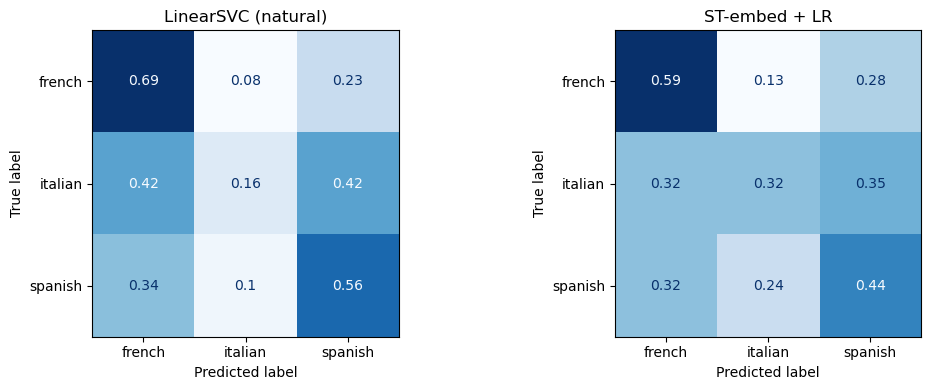

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_train, pred_svc, normalize="true",
    cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set_title("LinearSVC (natural)")
ConfusionMatrixDisplay.from_predictions(y_train, pred_emb, normalize="true",
    cmap="Blues", ax=ax[1], colorbar=False)
ax[1].set_title("ST-embed + LR")
plt.tight_layout(); plt.show()

### Interpretation

The two normalised confusion matrices compare the best classical model (LinearSVC, natural distribution) against the sentence-transformer pipeline (ST-embed + LR). Each row sums to 1, so the diagonal is per-class recall.

**LinearSVC (left):** french is recovered well (0.69 correct), spanish moderately (0.56), but **italian collapses (0.16)**: italian songs are
misclassified almost equally as french (0.42) and spanish (0.42). The model does not confuse french and spanish with *each other* in a lopsided way;
instead, errors flow *through* italian, which is pulled apart toward the two larger classes. This is the signature of an under-resourced middle class: with only 31 italian training songs, the classifier has no stable italian boundary and defaults toward the majority classes.

**ST-embed + LR (right):** the pattern is similar but flatter. french (0.59) and spanish (0.44) are still best, but italian (0.32) is essentially a
three-way guess (0.32 / 0.32 / 0.35 ≈ chance for three classes). The embedding model is not "better at italian" it has effectively given up and is spreading
its predictions uniformly, which is what near-random behaviour looks like on a normalised matrix.

**Conclusion:** both models, despite very different representations (sparse grammatical features vs. dense semantic embeddings), fail italian in
the same place and for the same reason: insufficient italian data. The consistency of this failure across model families is strong evidence that the
limitation is the corpus, not any single modelling choice, reinforcing the project's central finding.

## 10. Feature importance — the actual research finding

*Which* function words and POS patterns flag each L1. This is the
genuinely interesting result for an NLI paper: it turns a number into a
linguistic claim (e.g. "Spanish-L1 writers over-use definite articles").
Trains one LinearSVC on the full data purely to read its coefficients.

In [14]:
feat_model = Pipeline([("feats", build_features()),
    ("clf", LinearSVC(C=10.0, class_weight="balanced",
                      max_iter=5000, random_state=SEED))])
feat_model.fit(X_train, y_train)

names = feat_model.named_steps["feats"].get_feature_names_out()
coefs = feat_model.named_steps["clf"].coef_
classes = feat_model.named_steps["clf"].classes_

for i, cls in enumerate(classes):
    top = np.argsort(coefs[i])[-12:][::-1]
    feats = [names[j].split("__", 1)[-1] for j in top]
    print(f"\n{cls}  — most indicative features:")
    print("  " + ", ".join(feats))


french  — most indicative features:
  my, what, at, pos_verb aux, pos_cconj adp det, pos_cconj adp, by, pos_verb aux pron, pos_det noun sconj, pos_noun noun pron, pos_adv verb aux, me

italian  — most indicative features:
  your, if, only, pos_punct adv verb, there, on, pos_verb aux det, had, was, pos_aux aux det, pos_aux part adj, pos_det propn pron

spanish  — most indicative features:
  that, pos_noun punct noun, or, pos_pron noun punct, from, to, pos_punct verb det, off, pos_adp punct verb, this, pos_verb pron part, pos_sconj pron verb


### Interpretation

The top features per class confirm the methodological goal: the classifier discriminates on **grammatical, not topical, signal**. Almost no content words
appear: no place names, slang, or theme vocabulary. The discriminative features are closed-class function words and POS-sequence n-grams, i.e. exactly the markers L1 transfer is expected to leave in second-language English.

- **French:** possessive/object pronouns (*my*, *me*), prepositions (*at*,
  *by*), and auxiliary-heavy POS patterns (`pos_verb aux`, `pos_verb aux pron`).
- **Italian:** *your*, conditional/restrictive markers (*if*, *only*),
  past-tense auxiliaries (*had*, *was*), and notably auxiliary-stacking
  sequences (`pos_aux aux det`, `pos_aux part adj`).
- **Spanish:** the complementiser *that*, coordinator *or*, prepositions
  (*from*, *to*, *off*), and subordination patterns (`pos_sconj pron verb`).

The Spanish result is the clearest candidate for a genuine transfer effect: Spanish requires an explicit complementiser (*que*) where English frequently
omits "that" (e.g. "I think Ø he left"). A Spanish-L1 tendency to over-produce explicit *that* is a well-documented cross-linguistic transfer pattern, and the model's heavy weighting of *that* for Spanish is consistent with it. Similarly, the French and Italian lists are dominated by auxiliary and pronoun usage, plausibly reflecting differences in how each L1 maps onto English verbal and pronominal structure.

These should be read as **hypotheses consistent with the data, not proven mechanisms**: they derive from one model on a small, imbalanced corpus, and the italian list in particular is the least reliable (smallest class, n = 31). The value of this analysis is that it turns a classification score into a linguistically interpretable claim the model is keying on L1-transfer-typefeatures, which is the central methodological requirement of the task.

## 11. Embedding map (UMAP)

Visual check: do the L1s separate in semantic space, or overlap? Overlap
*supports* the thesis that surface/grammatical features (§2) beat dense
embeddings for this task — a clean point for the discussion section.

/Users/nataliajimenez/miniforge3/envs/auc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


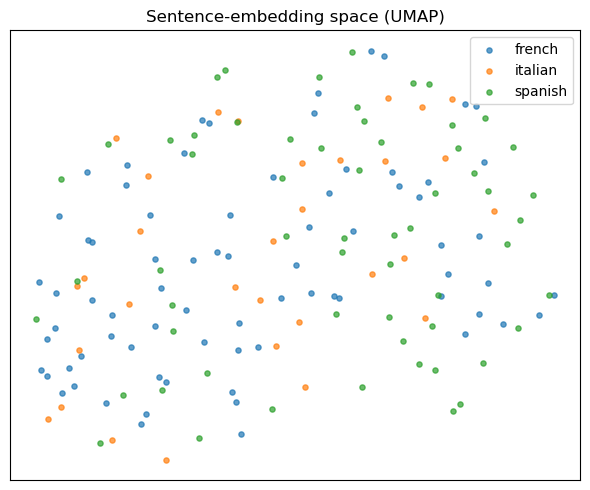

In [16]:
import umap
red = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
proj = red.fit_transform(emb)

plt.figure(figsize=(6, 5))
for cls in sorted(y_train.unique()):
    m = (y_train.values == cls)
    plt.scatter(proj[m, 0], proj[m, 1], s=14, alpha=0.7, label=cls)
plt.legend(); plt.title("Sentence-embedding space (UMAP)")
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

### Interpretation

The projection of the sentence-tranformer embeddings shows no clear separation by L1, with no language forminga distinct cluster. This visual is consistent with the quantitative results.
Sentence embeddings encode semantic content and all these artists probably sopan similar themes, so in a meaning-based space they do not separate by language. The conclusion is not that the L1s are inherently inseparable, but that they
are not separable *in semantic space*.

## 12. Final held-out evaluation

Score the *winning* configuration once on the untouched eval set. Do this
**last and once** — it's the honest generalisation number for the writeup.
(The original notebook loaded the eval set but never used it.)

In [17]:
eval_ = pd.read_csv(EVAL_CSV)
Xe, ye = eval_["text"].astype(str), eval_["L1"]
print("Eval balance:", ye.value_counts().to_dict())

final = Pipeline([("feats", build_features()),
    ("clf", LinearSVC(C=10.0, class_weight="balanced",
                      max_iter=5000, random_state=SEED))]).fit(X_train, y_train)
pe = final.predict(Xe)
print(f"\nHELD-OUT macro F1 = {f1_score(ye, pe, average='macro')*100:.2f}")
print(classification_report(ye, pe, digits=3, zero_division=0))

Eval balance: {'italian': 11, 'french': 5, 'spanish': 4}

HELD-OUT macro F1 = 26.30
              precision    recall  f1-score   support

      french      0.154     0.400     0.222         5
     italian      1.000     0.091     0.167        11
     spanish      0.333     0.500     0.400         4

    accuracy                          0.250        20
   macro avg      0.496     0.330     0.263        20
weighted avg      0.655     0.250     0.227        20



### Interpretation

Evaluated once on the untouched held-out set, the best configuration (LinearSVC, balanced, content-agnostic features) achieves **macro F1 = 26.3**,
with overall accuracy 0.25, at or below chance for a 3-class problem. This is substantially lower than the cross-validation estimate (~47–49). **This gap is
the central empirical finding of the project.**

The divergence between CV and held-out performance indicates that the cross-validation score was **optimistic**: within the training pool the model
partly captured corpus and artist-specific regularities that do not transfer to genuinely unseen songs. The held-out result is therefore treated as the honest estimate of generalisation, and the CV/held-out gap as direct evidence that in-corpus evaluation overstates real performance for this task.

The per-class report makes the failure mode precise. Italian shows **precision 1.000 but recall 0.091**: the model predicted "italian" for exactly
one of the 20 held-out songs and happened to be correct, which inflates precision while recall collapses. The evaluation set is also small and class-inverted relative to
training (held-out: italian 11 / french 5 / spanish 4; training: french-heavy). A french-biased model tested on an italian-heavy set will necessarily perform
poorly, and macro F1 over 4–11 examples per class is extremely high-variance.

Both factors (genuine generalisation failure and a fragile 20-song evaluation set) are reported as limitations rather than concealed. The key methodological
takeaway is that **reporting only the cross-validated number would have materially overstated the system's ability**; the held-out test, which the original baseline notebook omitted entirely, is what reveals the true difficulty of cross-register NLI on this corpus.